















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































# 1.Import


In [24]:
import sys
!{sys.executable} -m pip install statsmodels 


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
!{sys.executable} -m pip install pmdarima


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from pmdarima import auto_arima


plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11
})

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [27]:
import os
print(os.getcwd())

c:\Users\david.trueba\OneDrive - Universidad de Deusto\Escritorio\ML2 Proyecto\Electric-Power-Consumption\Sarimax


# 2.Load and preprocessing  

In [28]:
df = pd.read_csv('C:/Users/david.trueba/OneDrive - Universidad de Deusto/Escritorio/ML2 Proyecto/Electric-Power-Consumption/powerconsumption.csv', parse_dates=['Datetime'])
df.set_index('Datetime', inplace=True)

# Remuestrear a frecuencia horaria
df_hourly = df.resample('h').mean()

print(f'Registros originales (10 min): {len(df):,}')
print(f'Registros horarios:            {len(df_hourly):,}')
print(f'Período: {df_hourly.index.min()} → {df_hourly.index.max()}')
print(f'\nValores nulos tras resample: {df_hourly.isnull().sum().sum()}')

df_hourly.head()

Registros originales (10 min): 52,416
Registros horarios:            8,736
Período: 2017-01-01 00:00:00 → 2017-12-30 23:00:00

Valores nulos tras resample: 0


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
Datetime,,,,,,,,
2017-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,18026.747720,19252.048193
2017-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,16078.419453,17042.891567
2017-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,14330.699088,15676.144578
2017-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,13219.452887,14883.855422
2017-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,12921.580547,14317.108433


In [29]:
# Serie objetivo y variables exógenas
TARGET = 'PowerConsumption_Zone1'
EXOG_COLS = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows']

y = df_hourly[TARGET]
X = df_hourly[EXOG_COLS]

print(f'Serie objetivo : {TARGET}')
print(f'Variables exógenas: {EXOG_COLS}')
print(f'\nEstadísticas de las exógenas:')
X.describe().round(3)

Serie objetivo : PowerConsumption_Zone1
Variables exógenas: ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows']

Estadísticas de las exógenas:


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows
count,8736.000,8736.000,8736.000,8736.000,8736.000
mean,18.810,68.260,1.959,182.697,75.028
std,5.808,15.476,2.341,260.820,119.692
min,3.602,12.710,0.055,0.019,0.040
25%,14.404,58.325,0.078,0.064,0.124
50%,18.759,69.816,0.086,9.947,8.241
75%,22.867,81.350,4.915,326.488,105.883
max,39.695,94.750,5.934,953.350,861.000


# 3. Train/test split and exogenous variables scaling 

In [30]:
TEST_HOURS = 168   # 7 días
TRAIN_SEASONAL = 2160  # últimos 90 días para el modelo estacional (evita MemoryError)

# Split completo para exógenas
y_train_full = y.iloc[:-TEST_HOURS]
y_test        = y.iloc[-TEST_HOURS:]
X_train_full  = X.iloc[:-TEST_HOURS]
X_test        = X.iloc[-TEST_HOURS:]

# Reducido para SARIMAX (últimos 90 días de train + test)
y_train  = y_train_full.iloc[-TRAIN_SEASONAL:]
X_train  = X_train_full.iloc[-TRAIN_SEASONAL:]

# Escalar las variables exógenas
scaler = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index, columns=EXOG_COLS
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index, columns=EXOG_COLS
)

print(f'Train (reducido): {len(y_train):,} horas ({len(y_train)//24} días)')
print(f'Test:             {len(y_test):,} horas ({len(y_test)//24} días)')
print(f'Train: {y_train.index.min()} → {y_train.index.max()}')
print(f'Test : {y_test.index.min()}  → {y_test.index.max()}')

Train (reducido): 2,160 horas (90 días)
Test:             168 horas (7 días)
Train: 2017-09-25 00:00:00 → 2017-12-23 23:00:00
Test : 2017-12-24 00:00:00  → 2017-12-30 23:00:00


# 4.AutoArima searching

In [ ]:
#Usamos autoarima para encontrar los mejores parametros, en este caso usamos las variables exogenas

auto_model = auto_arima(
    y_train,
    X=X_train_sc,             # Variables exógenas escaladas
    seasonal=True,
    m=24,
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True,
    trace=True
)

order          = auto_model.order
seasonal_order = auto_model.seasonal_order

print(f'\n✅ Órdenes seleccionados: SARIMAX{order}x{seasonal_order}')
print(f'   AIC: {auto_model.aic():.2f}')
print(f'   BIC: {auto_model.bic():.2f}')

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=31.29 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=39803.202, Time=0.13 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=inf, Time=28.91 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=37708.691, Time=11.19 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=54218.715, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[24] intercept   : AIC=38955.209, Time=0.60 sec
 ARIMA(0,1,1)(1,0,1)[24] intercept   : AIC=35098.457, Time=23.54 sec
 ARIMA(0,1,1)(1,0,0)[24] intercept   : AIC=35637.655, Time=23.00 sec
 ARIMA(0,1,1)(2,0,1)[24] intercept   : AIC=35305.795, Time=85.06 sec
 ARIMA(0,1,1)(1,0,2)[24] intercept   : AIC=35134.093, Time=78.46 sec
 ARIMA(0,1,1)(0,0,2)[24] intercept   : AIC=37066.800, Time=45.87 sec
 ARIMA(0,1,1)(2,0,0)[24] intercept   : AIC=35534.580, Time=212.25 sec


# 5. Sarimax settings 


In [ ]:
sarimax_model = SARIMAX(
    y_train,
    exog=X_train_sc,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False)

print('\n✅ Modelo ajustado')
print(f'   AIC: {sarimax_result.aic:.2f}')
print(f'   BIC: {sarimax_result.bic:.2f}')


✅ Modelo ajustado
   AIC: 34378.31
   BIC: 34429.30


In [ ]:
print(sarimax_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:             PowerConsumption_Zone1   No. Observations:                 2160
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 24)   Log Likelihood              -17180.156
Date:                            Tue, 12 May 2026   AIC                          34378.313
Time:                                    11:28:36   BIC                          34429.301
Sample:                                09-25-2017   HQIC                         34396.974
                                     - 12-23-2017                                         
Covariance Type:                              opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Temperature          3734.0278     97.381     38.345      0.000    3543.165    3924.891
Humidity

Coeficientes de variables exógenas (sobre datos escalados):
Variable                        Coef    p-valor   Significativa
-----------------------------------------------------------------
Temperature                  3734.03     0.0000   ✅ Sí (p<0.05)
Humidity                     1197.72     0.0000   ✅ Sí (p<0.05)
WindSpeed                     136.71     0.0262   ✅ Sí (p<0.05)
GeneralDiffuseFlows            46.46     0.2076            ❌ No
DiffuseFlows                 -588.22     0.0000   ✅ Sí (p<0.05)


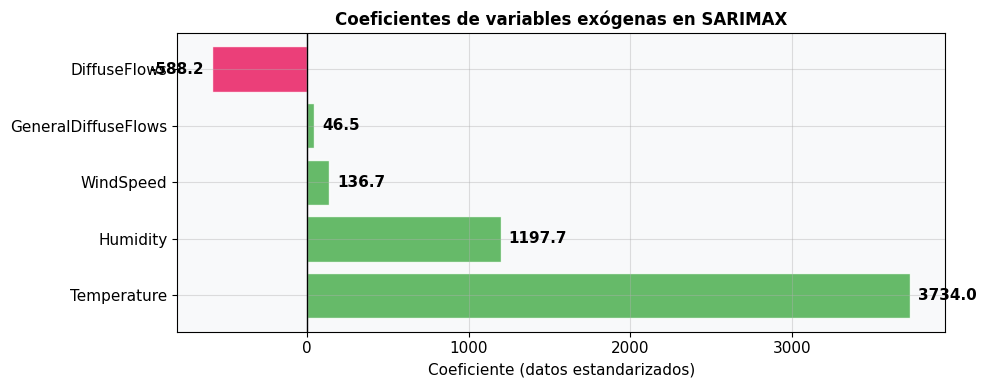

In [ ]:
# Extraer coeficientes de las variables exógenas
params = sarimax_result.params
pvalues = sarimax_result.pvalues
conf_int = sarimax_result.conf_int()

exog_params = {col: params[col] for col in EXOG_COLS if col in params.index}
exog_pvals  = {col: pvalues[col] for col in EXOG_COLS if col in pvalues.index}

print('Coeficientes de variables exógenas (sobre datos escalados):')
print(f'{"Variable":25s} {"Coef":>10s} {"p-valor":>10s} {"Significativa":>15s}')
print('-' * 65)
for col in EXOG_COLS:
    if col in exog_params:
        coef = exog_params[col]
        pval = exog_pvals[col]
        sig  = '✅ Sí (p<0.05)' if pval < 0.05 else '❌ No'
        print(f'{col:25s} {coef:>10.2f} {pval:>10.4f} {sig:>15s}')

# Visualización de coeficientes
fig, ax = plt.subplots(figsize=(10, 4))
coef_vals  = [exog_params[c] for c in EXOG_COLS if c in exog_params]
coef_names = [c for c in EXOG_COLS if c in exog_params]
ci_low  = [conf_int.loc[c, 'lower ' + c] if 'lower ' + c in conf_int.columns else conf_int.iloc[conf_int.index.get_loc(c), 0] for c in coef_names]
ci_high = [conf_int.loc[c, 'upper ' + c] if 'upper ' + c in conf_int.columns else conf_int.iloc[conf_int.index.get_loc(c), 1] for c in coef_names]
colors_coef = ['#4CAF50' if v > 0 else '#E91E63' for v in coef_vals]
bars = ax.barh(coef_names, coef_vals, color=colors_coef, edgecolor='white', alpha=0.85)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Coeficientes de variables exógenas en SARIMAX', fontsize=12, fontweight='bold')
ax.set_xlabel('Coeficiente (datos estandarizados)')
for bar, val in zip(bars, coef_vals):
    ax.text(val + (50 if val >= 0 else -50), bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', ha='left' if val >= 0 else 'right', fontweight='bold')
plt.tight_layout()
plt.show()

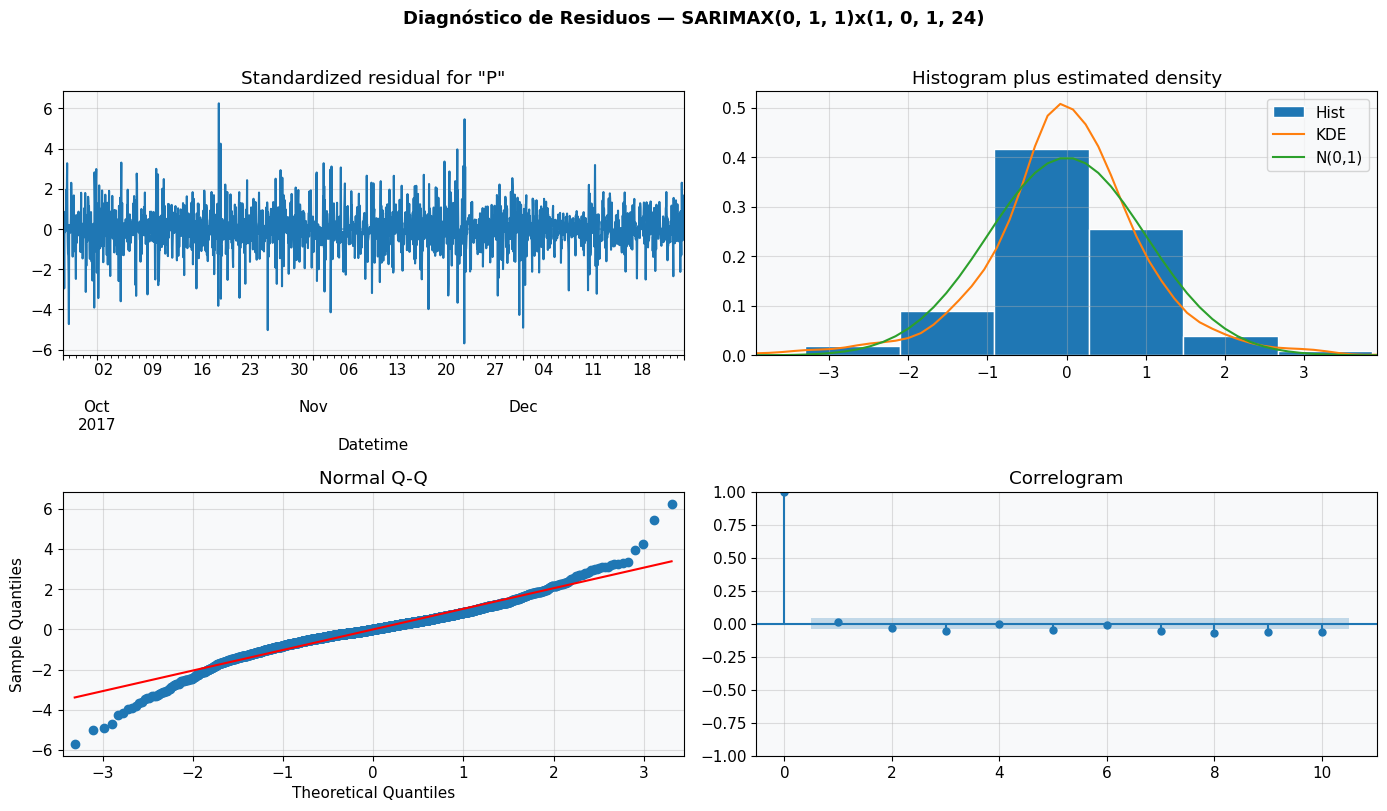

In [ ]:
sarimax_result.plot_diagnostics(figsize=(14, 8))
plt.suptitle(f'Diagnóstico de Residuos — SARIMAX{order}x{seasonal_order}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 6. Prediction in the test set

In [ ]:
# Forecast con variables exógenas del test
forecast_result = sarimax_result.get_forecast(steps=TEST_HOURS, exog=X_test_sc)
forecast_mean   = forecast_result.predicted_mean
forecast_ci     = forecast_result.conf_int(alpha=0.05)

forecast_mean.index = y_test.index
forecast_ci.index   = y_test.index

# Métricas
mae  = mean_absolute_error(y_test, forecast_mean)
rmse = np.sqrt(mean_squared_error(y_test, forecast_mean))
mape = np.mean(np.abs((y_test.values - forecast_mean.values) / y_test.values)) * 100

print(f'📈 Resultados — SARIMAX{order}x{seasonal_order}')
print(f'   MAE    : {mae:.2f} kW')
print(f'   RMSE   : {rmse:.2f} kW')
print(f'   MAPE   : {mape:.2f} %')

📈 Resultados — SARIMAX(0, 1, 1)x(1, 0, 1, 24)
   MAE    : 3422.73 kW
   RMSE   : 4052.55 kW
   MAPE   : 12.67 %


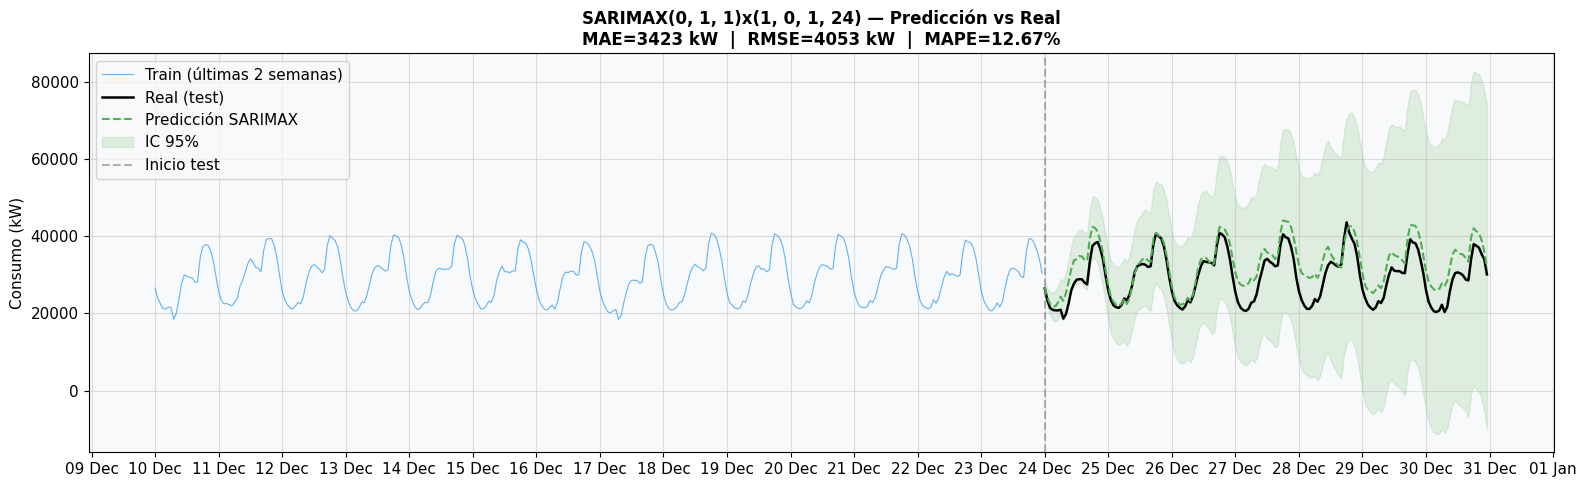

In [ ]:
# Visualización de la predicción
fig, ax = plt.subplots(figsize=(16, 5))

# Últimas 2 semanas de train para contexto
train_plot = y_train.iloc[-336:]
ax.plot(train_plot.index, train_plot.values,
        color='#2196F3', linewidth=0.8, alpha=0.7, label='Train (últimas 2 semanas)')
ax.plot(y_test.index, y_test.values,
        color='black', linewidth=1.8, label='Real (test)')
ax.plot(forecast_mean.index, forecast_mean.values,
        color='#4CAF50', linewidth=1.5, linestyle='--', label='Predicción SARIMAX')
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='#4CAF50', alpha=0.15, label='IC 95%'
)
ax.axvline(x=y_test.index[0], color='gray', linestyle='--', alpha=0.6, label='Inicio test')
ax.set_title(
    f'SARIMAX{order}x{seasonal_order} — Predicción vs Real\n'
    f'MAE={mae:.0f} kW  |  RMSE={rmse:.0f} kW  |  MAPE={mape:.2f}%',
    fontsize=12, fontweight='bold'
)
ax.set_ylabel('Consumo (kW)')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.tight_layout()
plt.show()

In [ ]:
# Ajustamos SARIMA con los mismos órdenes pero SIN variables exógenas
print(f'⚙️  Ajustando SARIMA{order}x{seasonal_order} sin variables exógenas...')

sarima_model = SARIMAX(
    y_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result = sarima_model.fit(disp=False)

# Predicción SARIMA en test
sarima_forecast = sarima_result.get_forecast(steps=TEST_HOURS)
sarima_mean     = sarima_forecast.predicted_mean
sarima_ci       = sarima_forecast.conf_int(alpha=0.05)
sarima_mean.index = y_test.index
sarima_ci.index   = y_test.index

# Métricas SARIMA
sarima_mae  = mean_absolute_error(y_test, sarima_mean)
sarima_rmse = np.sqrt(mean_squared_error(y_test, sarima_mean))
sarima_mape = np.mean(np.abs((y_test.values - sarima_mean.values) / y_test.values)) * 100

print(f'\n✅ SARIMA ajustado')
print(f'   AIC  : {sarima_result.aic:.2f}')
print(f'   MAE  : {sarima_mae:.2f} kW')
print(f'   RMSE : {sarima_rmse:.2f} kW')
print(f'   MAPE : {sarima_mape:.2f} %')

In [ ]:
# Visualización comparativa SARIMA vs SARIMAX
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('SARIMA vs SARIMAX — Predicción vs Real', fontsize=14, fontweight='bold')

train_plot = y_train.iloc[-336:]

for ax, (fc, ci, title, color) in zip(axes, [
    (sarima_mean, sarima_ci,
     f'SARIMA{order}x{seasonal_order} (sin exógenas)  |  MAPE={sarima_mape:.2f}%', '#FF9800'),
    (forecast_mean, forecast_ci,
     f'SARIMAX{order}x{seasonal_order} (con exógenas)  |  MAPE={mape:.2f}%', '#4CAF50'),
]):
    ax.plot(train_plot.index, train_plot.values, color='#2196F3', linewidth=0.8, alpha=0.6, label='Train')
    ax.plot(y_test.index, y_test.values, color='black', linewidth=1.8, label='Real')
    ax.plot(fc.index, fc.values, color=color, linewidth=1.5, linestyle='--', label='Predicción')
    ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color=color, alpha=0.15, label='IC 95%')
    ax.axvline(x=y_test.index[0], color='gray', linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Consumo (kW)')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.tight_layout()
plt.show()

In [ ]:
# Tabla comparativa de métricas
comparison = pd.DataFrame({
    'Modelo':             [f'SARIMA{order}x{seasonal_order}', f'SARIMAX{order}x{seasonal_order}'],
    'Variables exógenas': ['Ninguna', ', '.join(EXOG_COLS)],
    'AIC':      [round(sarima_result.aic, 2),  round(sarimax_result.aic, 2)],
    'MAE':      [round(sarima_mae, 2),          round(mae, 2)],
    'RMSE':     [round(sarima_rmse, 2),         round(rmse, 2)],
    'MAPE (%)': [round(sarima_mape, 2),         round(mape, 2)]
})

print('=' * 80)
print('TABLA COMPARATIVA — SARIMA vs SARIMAX')
print('=' * 80)
print(comparison.to_string(index=False))
print('=' * 80)

mejora_mape = sarima_mape - mape
mejora_mae  = sarima_mae  - mae
print(f'\n📊 Efecto de añadir variables exógenas:')
print(f'   MAPE : {sarima_mape:.2f}% → {mape:.2f}%  ({mejora_mape:+.2f} pp)')
print(f'   MAE  : {sarima_mae:.0f} → {mae:.0f} kW  ({mejora_mae:+.0f} kW)')
if mejora_mape > 0:
    print(f'\n   ✅ SARIMAX mejora al SARIMA gracias a las variables exógenas.')
else:
    print(f'\n   ⚠️  SARIMAX no mejora al SARIMA. Las exógenas no aportan información adicional significativa.')

NameError: name 'sarima_mae' is not defined

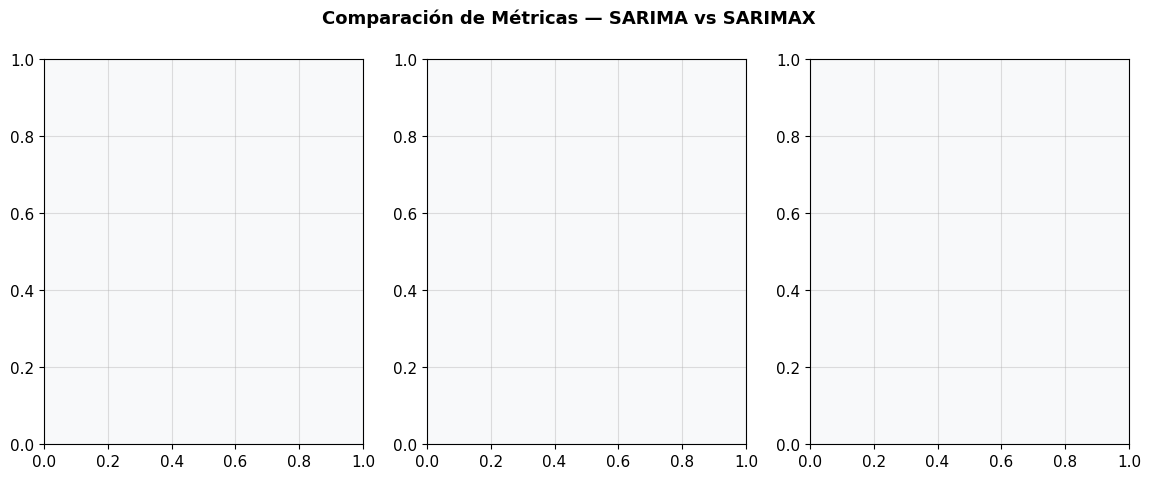

In [ ]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Comparación de Métricas — SARIMA vs SARIMAX', fontsize=13, fontweight='bold')

labels = ['SARIMA', 'SARIMAX']
colors = ['#FF9800', '#4CAF50']

for ax, (vals, metric_name) in zip(axes, [
    ([sarima_mae,  mae],  'MAE (kW)'),
    ([sarima_rmse, rmse], 'RMSE (kW)'),
    ([sarima_mape, mape], 'MAPE (%)'),
]):
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
    ax.set_title(metric_name, fontsize=12)
    ax.set_ylim(0, max(vals) * 1.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()